In [2]:
train_dir = "D:\Herald\AI and ML\Coursework\Traffic_Sign_-2\Train"
test_dir = "D:\Herald\AI and ML\Coursework\Traffic_Sign_-2\Test"

In [3]:
!pip install numpy matplotlib seaborn scikit-learn pillow tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/351.2 MB 903.7 kB/s eta 0:06:29
   ---------------------------------------- 0.5/351.2 MB 903.7 kB/s eta 0:06:29
   ---------------------------------------- 0.8/351.2 MB 746.8 kB/s eta 0:07:50
   ---------------------------------------- 0.8/351.2 MB 746.8 kB/s eta 0:07:50
   ---------------------------------------- 0.8/351.2 MB 746.8 kB/s eta 0:07:50
   ---------------------------------------- 1.0/351.2 MB 633.3 kB/s eta 0:09:13
   ---------------------------------------- 1.3/351.2 MB 687.8 kB/s eta 0:08:29
   ---------------------------------------- 1.3/351.2 MB 687.8 kB/s eta 0:08:29
   ---------------------------------------- 1.6/351.2 MB 713.7 kB/s eta 0:08:10
   ---------------------------------------- 1.8/351.2 MB 743.3 kB/s

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [4]:
import os
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import load_model

import time

In [5]:
def total_images_through_classes(directory):
    class_totals = {}
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            class_totals[class_name] = len(image_files)
    return class_totals

In [6]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]


In [7]:
train_totals = total_images_through_classes(train_dir)

In [8]:
total_train_count = 0
total_valid_count = 0
print("Training Images:")
print("Classes:")
for classs, count in train_totals.items():
    total_train_count += count
    print(f"'{classs}': {count} images")
print()
print(f"Total Training Images Count: {total_train_count}")
print(f"Total Images Count: {total_train_count}")

Training Images:
Classes:
'Cautions': 1678 images
'Crossings': 1828 images
'DIrection': 2968 images
'No Entry': 2938 images
'SpeedLimit': 6688 images

Total Training Images Count: 16100
Total Images Count: 16100


In [10]:
import os
import shutil
import random

# Set paths
original_dataset_dir = 'D:\Herald\AI and ML\Coursework\Traffic_Sign_-2\Train'  # Original train folder
train_dir = original_dataset_dir  # You keep the training images here
test_dir = 'D:\Herald\AI and ML\Coursework\Traffic_Sign_-2\Test'  # Target test folder

# Create test directories if they don't exist
os.makedirs(test_dir, exist_ok=True)

# Set split ratio
test_ratio = 0.2
random.seed(42)

# Split images per class
for class_name in os.listdir(original_dataset_dir):
    class_path = os.path.join(original_dataset_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    images = os.listdir(class_path)
    random.shuffle(images)
    split_idx = int(len(images) * (1 - test_ratio))

    train_images = images[:split_idx]
    test_images = images[split_idx:]

    # Ensure test class folder exists
    os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

    # Move test images
    for img in test_images:
        src = os.path.join(class_path, img)
        dst = os.path.join(test_dir, class_name, img)
        shutil.move(src, dst)

    print(f"{class_name}: {len(train_images)} train / {len(test_images)} test")


Cautions: 1342 train / 336 test
Crossings: 1462 train / 366 test
DIrection: 2374 train / 594 test
No Entry: 2350 train / 588 test
SpeedLimit: 5350 train / 1338 test


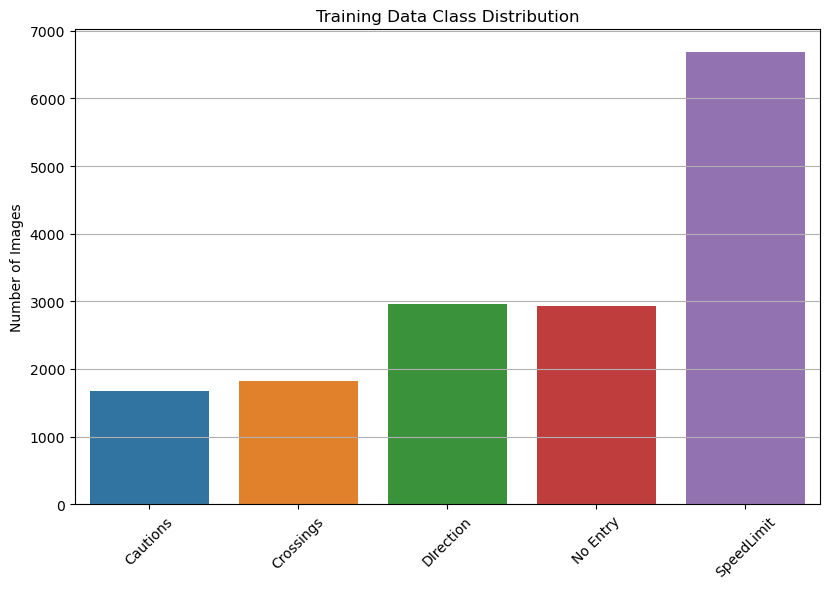

In [11]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.barplot(x=list(train_totals.keys()), y=list(train_totals.values()), hue=list(train_totals.keys()), legend=False)
plt.title('Training Data Class Distribution')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.tight_layout()
plt.show()

In [12]:
import os

test_path = "D:\Herald\AI and ML\Coursework\Traffic_Sign_-2\Test"
total_test = sum(
    len(files)
    for cls in os.listdir(test_path)
    if os.path.isdir(os.path.join(test_path, cls))
    for files in [os.listdir(os.path.join(test_path, cls))]
)
print(f"Images in test/: {total_test}")

Images in test/: 3222


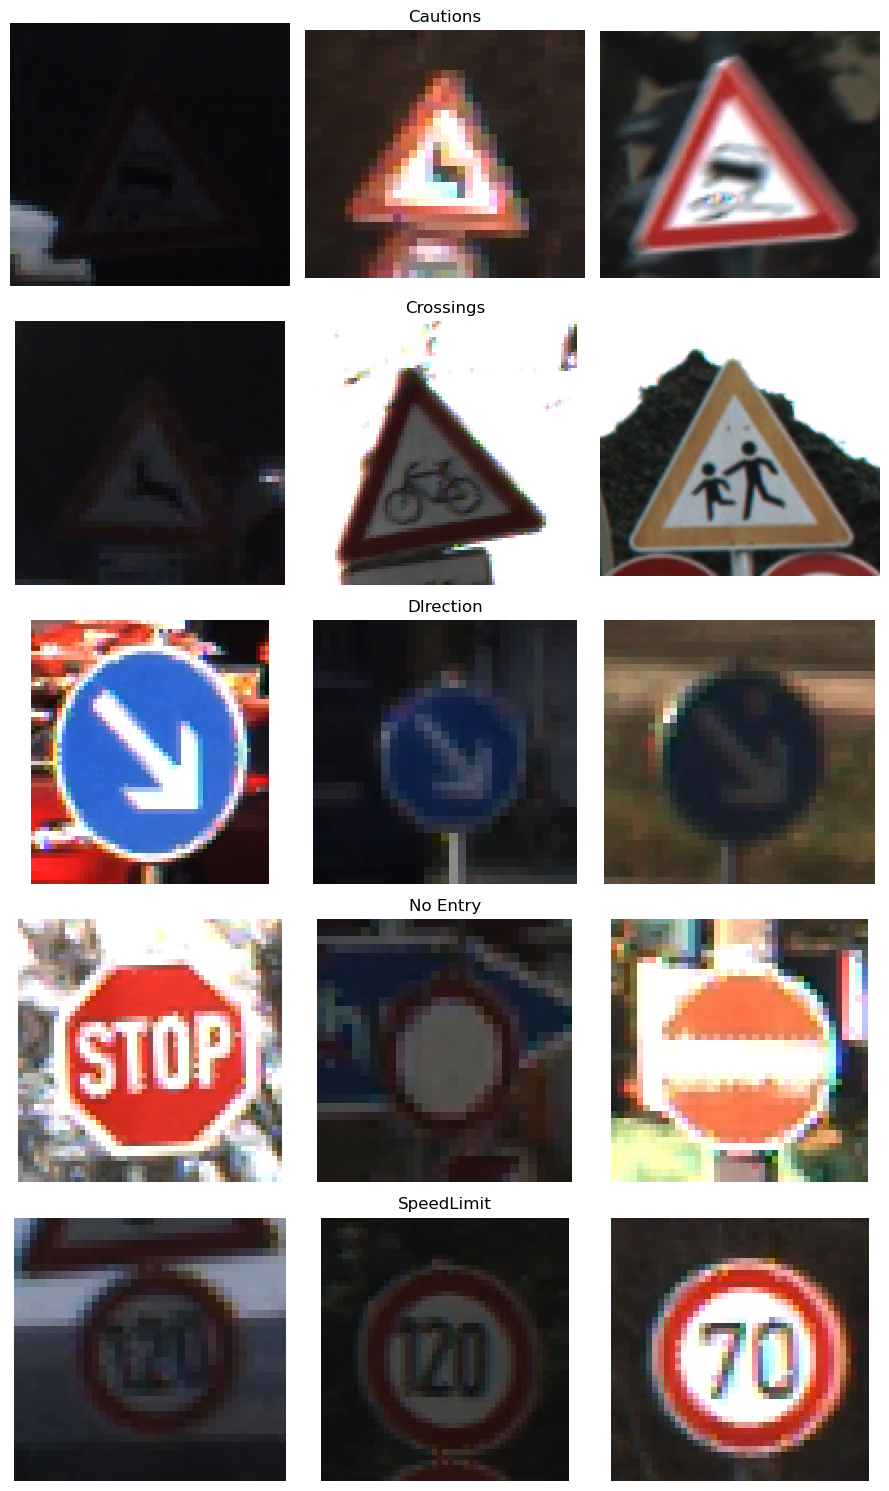

In [14]:
from PIL import Image, UnidentifiedImageError
import os
import random
import matplotlib.pyplot as plt

train_dir = "D:\Herald\AI and ML\Coursework\Traffic_Sign_-2\Train"
class_names = os.listdir(train_dir)

plt.figure(figsize=(3 * 3, len(class_names) * 3))

for i, cls in enumerate(class_names):
    cls_path = os.path.join(train_dir, cls)
    images = [img for img in os.listdir(cls_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
    selected_images = random.sample(images, min(3, len(images)))

    for j, img_name in enumerate(selected_images):
        img_path = os.path.join(cls_path, img_name)
        try:
            image = Image.open(img_path).convert('RGB')
            plt.subplot(len(class_names), 3, i * 3 + j + 1)
            plt.imshow(image)
            plt.axis('off')
            if j == 1:
                plt.title(cls)
        except UnidentifiedImageError:
            print(f" Skipping unreadable image: {img_path}")

plt.tight_layout()
plt.show()


In [15]:
def remove_corrupted_images(directory):
    removed = 0
    for subdir, _, files in os.walk(directory):
        for file in files:
            filepath = os.path.join(subdir, file)
            try:
                img = Image.open(filepath)
                img.verify()
            except (IOError, SyntaxError):
                print(f"Removing corrupt image: {filepath}")
                os.remove(filepath)
                removed += 1
    print(f"Total corrupt images removed: {removed}")

In [16]:
remove_corrupted_images(train_dir)
remove_corrupted_images(test_dir)

Removing corrupt image: D:\Herald\AI and ML\Coursework\Traffic_Sign_-2\Train\Cautions\00021_00004_00014.png
Removing corrupt image: D:\Herald\AI and ML\Coursework\Traffic_Sign_-2\Train\Cautions\00022_00006_00005.png
Removing corrupt image: D:\Herald\AI and ML\Coursework\Traffic_Sign_-2\Train\Cautions\00023_00007_00006.png
Removing corrupt image: D:\Herald\AI and ML\Coursework\Traffic_Sign_-2\Train\Cautions\00030_00004_00000.png
Removing corrupt image: D:\Herald\AI and ML\Coursework\Traffic_Sign_-2\Train\Crossings\00028_00000_00010.png
Removing corrupt image: D:\Herald\AI and ML\Coursework\Traffic_Sign_-2\Train\Crossings\00031_00012_00018.png
Removing corrupt image: D:\Herald\AI and ML\Coursework\Traffic_Sign_-2\Train\Crossings\00031_00021_00000.png
Removing corrupt image: D:\Herald\AI and ML\Coursework\Traffic_Sign_-2\Train\Crossings\00031_00024_00010.png
Removing corrupt image: D:\Herald\AI and ML\Coursework\Traffic_Sign_-2\Train\DIrection\00037_00006_00028.png
Removing corrupt image:

In [17]:
import os
from PIL import Image

def image_formats(folder_path):
    format_count = {}

    for subdir, _, files in os.walk(folder_path):
        for file in files:
            filepath = os.path.join(subdir, file)
            try:
                img = Image.open(filepath)
                img_format = img.format

                if img_format in format_count:
                    format_count[img_format] += 1
                else:
                    format_count[img_format] = 1
            except Exception as e:
                print(f"Error with image {filepath}: {e}")

    return format_count

formats_train = image_formats(train_dir)
formats_test = image_formats(test_dir)
print(formats_train)
print(formats_test)

{'PNG': 12854}
{'PNG': 3221}


In [18]:
def collect_image_sizes(root_dir):
    widths, heights = [], []
    image_count = 0
    for folder, _, files in os.walk(root_dir):
        for fname in files:
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                path = os.path.join(folder, fname)
                try:
                    with Image.open(path) as img:
                        w, h = img.size
                        widths.append(w)
                        heights.append(h)
                    image_count += 1
                except Exception as e:
                    print(f"Error processing file {fname}: {e}")

    if image_count == 0:
        print("No images were processed.")
        return np.array([]), np.array([])

    return np.array(widths), np.array(heights)

w, h = collect_image_sizes(train_dir)

if w.size > 0 and h.size > 0:
    print(f"Widths:  min={w.min()}, max={w.max()}, mean={w.mean():.1f}")
    print(f"Heights: min={h.min()}, max={h.max()}, mean={h.mean():.1f}")
else:
    print("No valid image sizes were found.")


Widths:  min=25, max=224, mean=48.6
Heights: min=25, max=219, mean=48.6


In [19]:
targetSize = (224, 224) #Target Size for resizing
batch_size = 32
num_classes = 8
validation_split = 0.2 #20% for validation

In [20]:
train_datagen = ImageDataGenerator(
    rescale = 1./255, # we're normalizing here from 0 to 1 (range of rgb values 1 to 255)
    rotation_range = 10,
    width_shift_range = 0.05,
    height_shift_range = 0.05,
    zoom_range = 0.05,
    horizontal_flip = True,
    validation_split = 0.2 ##20% of the data will be used for validation
)

#data augmentation is performed only for the training dataset


In [21]:
training_dataset = train_datagen.flow_from_directory(
    train_dir,
    target_size = targetSize,
    batch_size = batch_size,
    class_mode = 'sparse',
    shuffle = True,
    seed = 123,
    subset = "training"
)

Found 10286 images belonging to 5 classes.


In [22]:
validation_dataset = train_datagen.flow_from_directory(
    train_dir,
    target_size = targetSize,
    batch_size = batch_size,
    class_mode = 'sparse',
    shuffle = False,
    seed = 123,
    subset = "validation"
)

Found 2568 images belonging to 5 classes.


In [23]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_dataset = test_datagen.flow_from_directory(
    test_dir,
    target_size=targetSize,
    batch_size=32,
    class_mode='sparse',
    shuffle=False,
    seed=123
)

Found 3211 images belonging to 5 classes.


In [24]:
training_dataset.class_indices.items()

dict_items([('Cautions', 0), ('Crossings', 1), ('DIrection', 2), ('No Entry', 3), ('SpeedLimit', 4)])

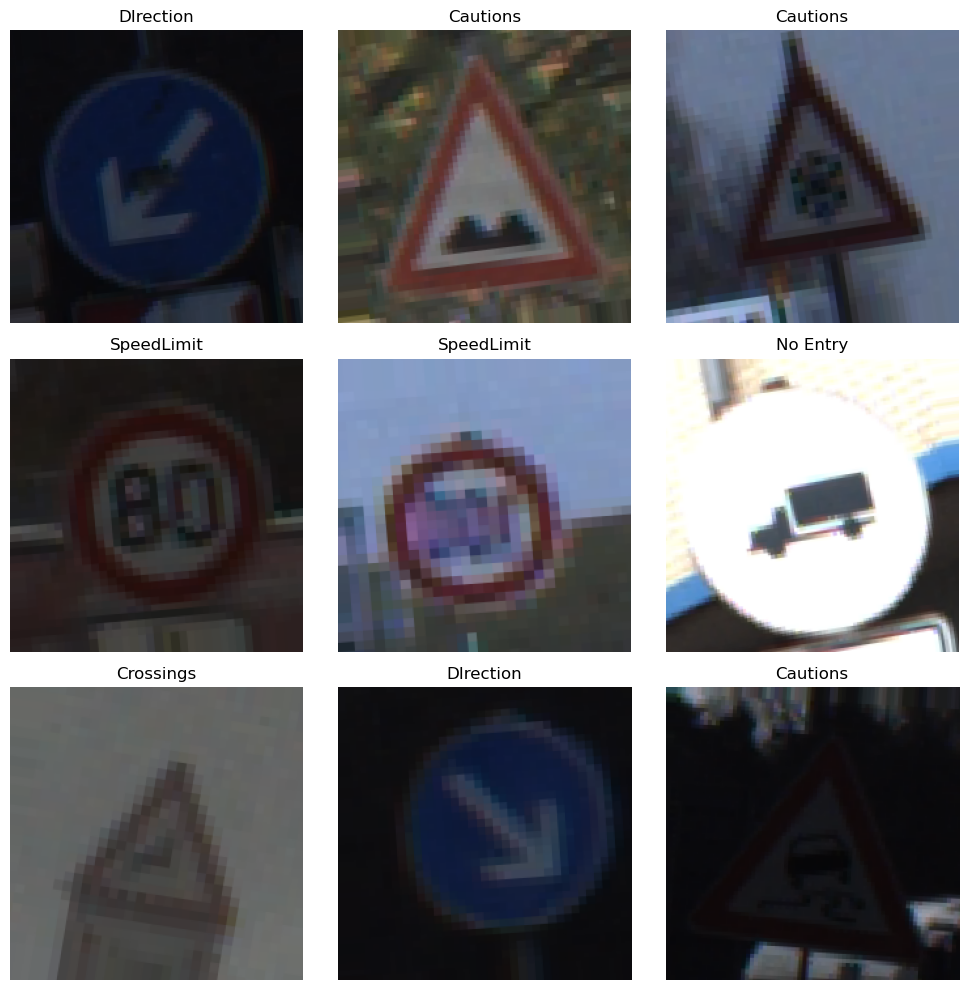

In [25]:
class_names = {}
for class_name, class_index in training_dataset.class_indices.items():
    class_names[class_index] = class_name
images, labels = next(training_dataset)

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    plt.title(f"{class_names[int(labels[i])]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [26]:
input_shape = (224, 224, 3)
num_classes = 9
batch_size = 32


baseline_adam_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

baseline_adam_model.summary()

C:\Users\spktd\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,179,593 (42.65 MB)

 Trainable params: 11,179,593 (42.65 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

def build_model():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D(2, 2),

        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),

        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),

        Flatten(),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    return model


In [28]:
callbacks = [
    ModelCheckpoint("best_model.keras", save_best_only=True, monitor="val_accuracy", mode="max"),
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
]


In [29]:
baseline_sgd_model = build_model()
baseline_sgd_model.compile(
    optimizer=SGD(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = baseline_sgd_model.fit(
    training_dataset,
    validation_data=validation_dataset,
    epochs=15,
    batch_size=batch_size,
    callbacks=callbacks
)


Epoch 1/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 205s 633ms/step - accuracy: 0.4795 - loss: 1.4136 - val_accuracy: 0.7391 - val_loss: 0.7280
Epoch 2/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 186s 577ms/step - accuracy: 0.7617 - loss: 0.5852 - val_accuracy: 0.8224 - val_loss: 0.4149
Epoch 3/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 184s 570ms/step - accuracy: 0.8277 - loss: 0.3999 - val_accuracy: 0.7792 - val_loss: 0.4129
Epoch 4/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 207s 643ms/step - accuracy: 0.8579 - loss: 0.3309 - val_accuracy: 0.8174 - val_loss: 0.3506
Epoch 5/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 231s 717ms/step - accuracy: 0.8785 - loss: 0.2865 - val_accuracy: 0.8080 - val_loss: 0.3790
Epoch 6/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 234s 728ms/step - accuracy: 0.8936 - loss: 0.2528 - val_accuracy: 0.8376 - val_loss: 0.3098
Epoch 7/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 230s 715ms/step - accuracy: 0.9074 - loss: 0.2186 - val_accuracy: 0.8049 - val_loss: 0.4133
Epoch 8/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 236s 734ms/step - accuracy: 0.9202 -

In [32]:
baseline_adam_model = build_model()
baseline_adam_model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_adam = baseline_adam_model.fit(
    training_dataset,
    validation_data=validation_dataset,
    epochs=15,
    batch_size=batch_size,
    callbacks=callbacks
)


Epoch 1/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 212s 653ms/step - accuracy: 0.8042 - loss: 0.4618 - val_accuracy: 0.8162 - val_loss: 0.3804
Epoch 2/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 200s 619ms/step - accuracy: 0.8966 - loss: 0.2418 - val_accuracy: 0.8769 - val_loss: 0.4035
Epoch 3/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 199s 616ms/step - accuracy: 0.9451 - loss: 0.1432 - val_accuracy: 0.8917 - val_loss: 0.2658
Epoch 4/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 199s 617ms/step - accuracy: 0.9595 - loss: 0.1085 - val_accuracy: 0.9089 - val_loss: 0.2395
Epoch 5/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 199s 617ms/step - accuracy: 0.9707 - loss: 0.0868 - val_accuracy: 0.8964 - val_loss: 0.3910
Epoch 6/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 198s 614ms/step - accuracy: 0.9818 - loss: 0.0543 - val_accuracy: 0.8738 - val_loss: 0.6281
Epoch 7/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 200s 620ms/step - accuracy: 0.9796 - loss: 0.0618 - val_accuracy: 0.8956 - val_loss: 0.4285
Epoch 8/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 199s 618ms/step - accuracy: 0.9871 -

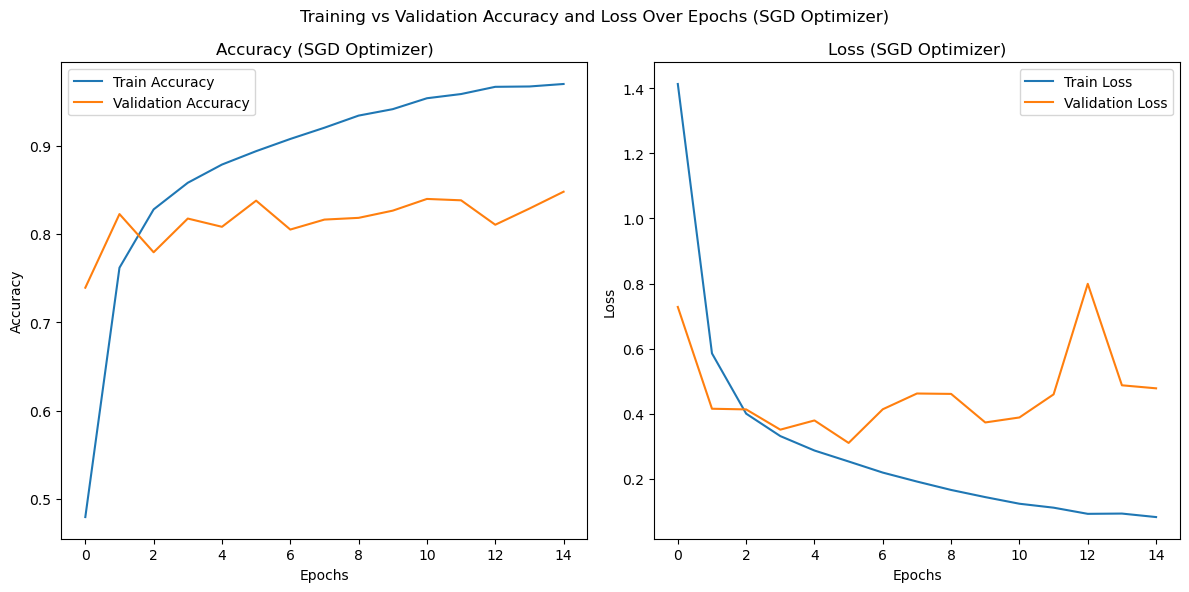

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history_sgd.history['accuracy'], label='Train Accuracy')
plt.plot(history_sgd.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy (SGD Optimizer)')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_sgd.history['loss'], label='Train Loss')
plt.plot(history_sgd.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss (SGD Optimizer)')

plt.suptitle('Training vs Validation Accuracy and Loss Over Epochs (SGD Optimizer)')
plt.tight_layout()
plt.show()


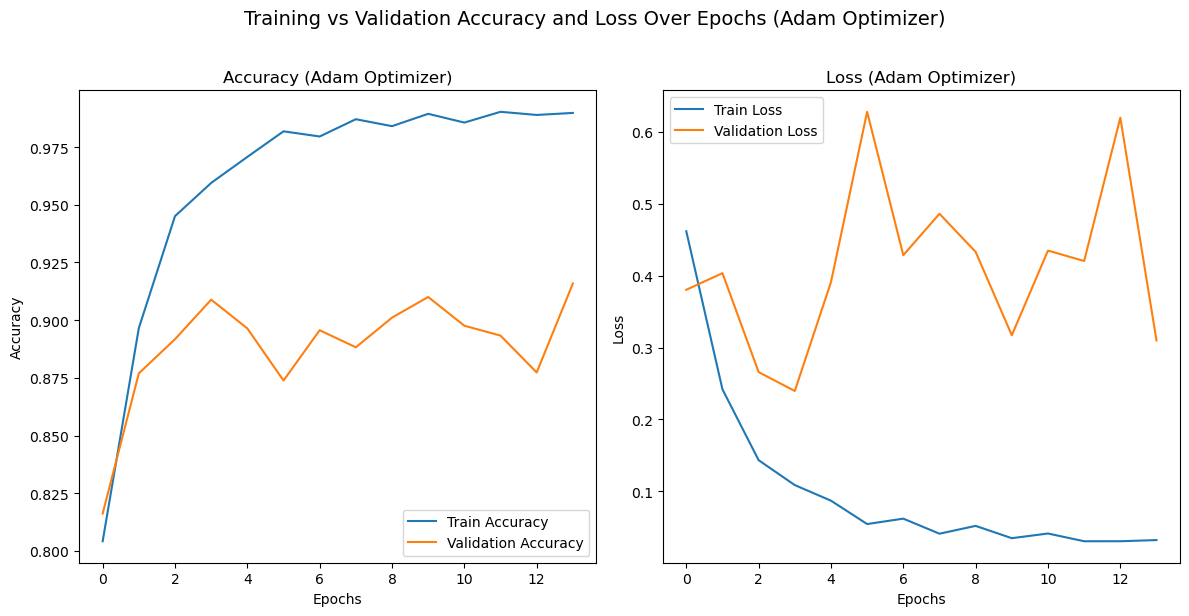

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Accuracy subplot
plt.subplot(1, 2, 1)
plt.plot(history_adam.history['accuracy'], label='Train Accuracy')
plt.plot(history_adam.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy (Adam Optimizer)')
plt.legend()

# Loss subplot
plt.subplot(1, 2, 2)
plt.plot(history_adam.history['loss'], label='Train Loss')
plt.plot(history_adam.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss (Adam Optimizer)')
plt.legend()

plt.suptitle("Training vs Validation Accuracy and Loss Over Epochs (Adam Optimizer)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [35]:
# Evaluate the model on the test dataset
test_loss, test_accuracy = baseline_sgd_model.evaluate(test_dataset)

# Print test results
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.9091 - loss: 0.2171
Test Loss: 0.2171
Test Accuracy: 0.9091


In [36]:
import numpy as np
from sklearn.metrics import classification_report

# Get true labels (only works if test_dataset is a DirectoryIterator or similar)
y_true = test_dataset.classes

# Predict labels
y_pred_probs = baseline_sgd_model.predict(test_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)

# Fix class names to only include those that are in y_true
all_class_names = list(test_dataset.class_indices.keys())
present_labels = np.unique(y_true)
present_class_names = [all_class_names[i] for i in present_labels]

# Print classification report
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, labels=present_labels, target_names=present_class_names))


101/101 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step
              precision    recall  f1-score   support

    Cautions       0.68      0.73      0.71       333
   Crossings       0.73      0.71      0.72       363
   DIrection       0.99      1.00      0.99       593
    No Entry       0.95      0.91      0.93       585
  SpeedLimit       0.96      0.97      0.96      1337

    accuracy                           0.91      3211
   macro avg       0.86      0.86      0.86      3211
weighted avg       0.91      0.91      0.91      3211



In [37]:
test_loss, test_accuracy = baseline_adam_model.evaluate(test_dataset)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

101/101 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.9748 - loss: 0.0757
Test Loss: 0.0757
Test Accuracy: 0.9748


In [38]:
# Get true and predicted labels
y_true = test_dataset.classes
y_pred_probs = baseline_adam_model.predict(test_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get all class names from the test dataset
all_class_names = list(test_dataset.class_indices.keys())

# Get only the class indices present in y_true
present_labels = sorted(np.unique(y_true))
present_class_names = [all_class_names[i] for i in present_labels]

# Print classification report for only present classes
print(classification_report(y_true, y_pred, labels=present_labels, target_names=present_class_names))


101/101 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step
              precision    recall  f1-score   support

    Cautions       0.91      0.89      0.90       333
   Crossings       0.90      0.92      0.91       363
   DIrection       1.00      1.00      1.00       593
    No Entry       0.98      0.99      0.99       585
  SpeedLimit       1.00      0.99      0.99      1337

    accuracy                           0.97      3211
   macro avg       0.96      0.96      0.96      3211
weighted avg       0.97      0.97      0.97      3211



101/101 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step


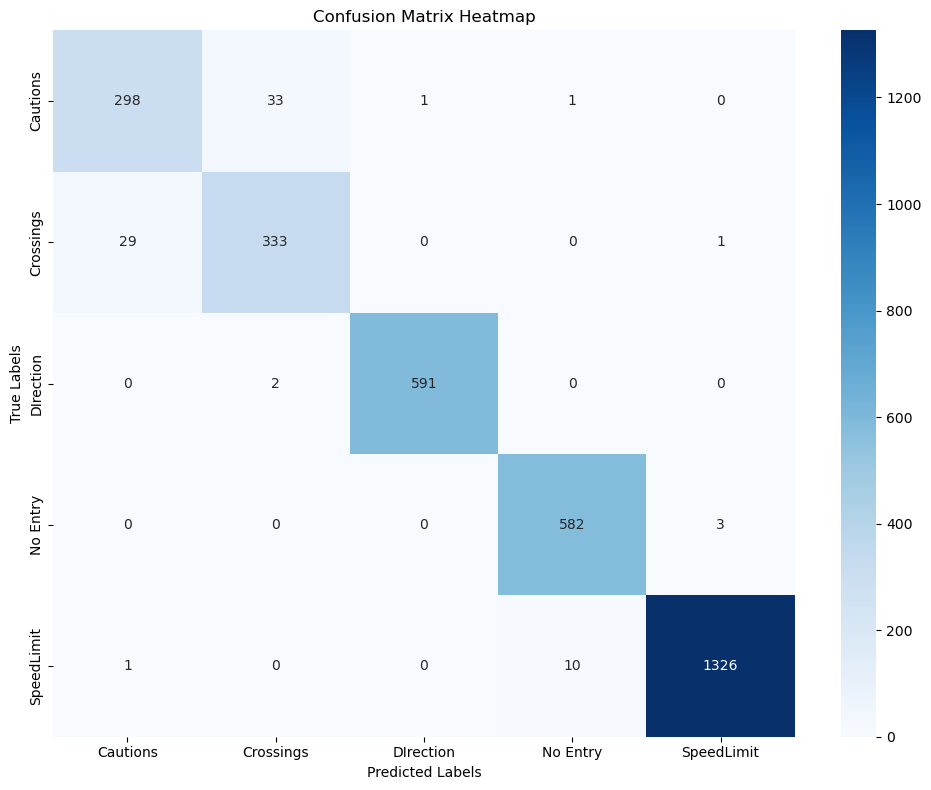

In [39]:
y_true = test_dataset.classes
y_pred_probs = baseline_adam_model.predict(test_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, 
            xticklabels=test_dataset.class_indices.keys(),
            yticklabels=test_dataset.class_indices.keys())
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')
plt.tight_layout()
plt.show()

In [40]:
input_shape = (224, 224, 3)
num_classes = 9

deeper_sgd_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.001), input_shape=input_shape),
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    MaxPooling2D(2, 2),

    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(num_classes, activation='softmax')
])

deeper_sgd_model.summary()
 

C:\Users\spktd\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 220, 220, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 106, 106, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 51, 51, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 49, 49, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 20, 20, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │     6,553,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,767,849 (29.63 MB)

 Trainable params: 7,767,849 (29.63 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
input_shape = (224, 224, 3)
num_classes = 9

deeper_sgd_model_2 = Sequential([
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.0005), input_shape=input_shape),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(256, activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),

    Dense(num_classes, activation='softmax')
])

deeper_sgd_model_2.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_25 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 220, 220, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 220, 220, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 108, 108, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 106, 106, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 106, 106, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 51, 51, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 51, 51, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 49, 49, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 49, 49, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 22, 22, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 20, 20, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 20, 20, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 25600)          │             

 Total params: 7,773,481 (29.65 MB)

 Trainable params: 7,770,665 (29.64 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [42]:
input_shape = (224, 224, 3)
num_classes = 9

deeper_adam_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.0005), input_shape=input_shape),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(256, activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),

    Dense(num_classes, activation='softmax')
])

deeper_adam_model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_33 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 220, 220, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 220, 220, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 108, 108, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 106, 106, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 106, 106, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 51, 51, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 51, 51, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 49, 49, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 49, 49, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 22, 22, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 20, 20, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 20, 20, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 25600)          │             

 Total params: 7,773,481 (29.65 MB)

 Trainable params: 7,770,665 (29.64 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [43]:
deeper_sgd_model.compile(
    optimizer=SGD(learning_rate=0.001, momentum=0.9), #setting the learning rate and the momentum (it helps in faster convergence and controls extreme oscillations)
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [44]:
callbacks_sgd = [
    ModelCheckpoint("deeper_sgd_model.keras", save_best_only=True, monitor="val_accuracy", mode="max"),
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5)
]

history_deeper_sgd = deeper_sgd_model.fit(
    training_dataset,
    validation_data=validation_dataset,
    epochs=15,
    callbacks=callbacks_sgd
)


Epoch 1/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 432s 1s/step - accuracy: 0.4061 - loss: 3.2198 - val_accuracy: 0.4159 - val_loss: 3.0131 - learning_rate: 0.0010
Epoch 2/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 415s 1s/step - accuracy: 0.4136 - loss: 2.9962 - val_accuracy: 0.5541 - val_loss: 2.8456 - learning_rate: 0.0010
Epoch 3/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 413s 1s/step - accuracy: 0.5899 - loss: 2.5674 - val_accuracy: 0.8224 - val_loss: 1.9899 - learning_rate: 0.0010
Epoch 4/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 414s 1s/step - accuracy: 0.7462 - loss: 2.1204 - val_accuracy: 0.8224 - val_loss: 1.8372 - learning_rate: 0.0010
Epoch 5/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 413s 1s/step - accuracy: 0.7886 - loss: 1.9466 - val_accuracy: 0.8236 - val_loss: 1.7957 - learning_rate: 0.0010
Epoch 6/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 413s 1s/step - accuracy: 0.8073 - loss: 1.8804 - val_accuracy: 0.8314 - val_loss: 1.7641 - learning_rate: 0.0010
Epoch 7/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 413s 1s/step - accuracy: 0.8240 - loss: 1.